1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


2. Load Dataset

In [ ]:
df = pd.read_excel("AI_Tools_In_Education_Dataset.xlsx")


3. Understand the Dataset



In [ ]:
df.shape          # Number of rows and columns


(20000, 16)

In [ ]:
df.info()         # Data types


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Unnamed: 0                     20000 non-null  int64         
 1   Country                        20000 non-null  object        
 2   Education_Level                20000 non-null  object        
 3   Subject_Focus                  20000 non-null  object        
 4   AI_Tool_Used                   17966 non-null  object        
 5   Usage_Frequency                20000 non-null  object        
 6   Primary_Device                 20000 non-null  object        
 7   Main_Use_Case                  20000 non-null  object        
 8   Hours_Studying_Per_Week        20000 non-null  float64       
 9   Hours_Using_AI_Per_Week        20000 non-null  float64       
 10  GPA                            19600 non-null  float64       
 11  Perceived_Helpf

4. Data Cleaning

In [ ]:
# Remove duplicate records
df.drop_duplicates(inplace=True)

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

5. Handle Missing Values

In [ ]:
# Numerical columns
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

6. Detect & Handle Outliers

In [ ]:
numeric = df.select_dtypes(include='number')

for col in numeric.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

7. Analyze the Data

In [ ]:
print(df.columns.tolist())

['Unnamed: 0', 'Country', 'Education_Level', 'Subject_Focus', 'AI_Tool_Used', 'Usage_Frequency', 'Primary_Device', 'Main_Use_Case', 'Hours_Studying_Per_Week', 'Hours_Using_AI_Per_Week', 'GPA', 'Perceived_Helpfulness_Score', 'Academic_Integrity_Concern', 'Parental_Awareness', 'Monthly_Subscription_Cost_USD', 'Survey_Date']


In [ ]:
for col in df.columns:
    print(col)

Unnamed: 0
Country
Education_Level
Subject_Focus
AI_Tool_Used
Usage_Frequency
Primary_Device
Main_Use_Case
Hours_Studying_Per_Week
Hours_Using_AI_Per_Week
GPA
Perceived_Helpfulness_Score
Academic_Integrity_Concern
Parental_Awareness
Monthly_Subscription_Cost_USD
Survey_Date


In [ ]:
print(df.groupby('AI_Tool_Used')['Perceived_Helpfulness_Score'].mean())


AI_Tool_Used
ChatGPT               7.056457
Duolingo Max          7.245669
Google Bard/Gemini    7.224187
Grammarly             7.276893
Khanmigo              7.268451
Notion AI             7.174427
Photomath             7.271461
Quizlet AI            7.256642
Name: Perceived_Helpfulness_Score, dtype: float64


8. Visualize the Data

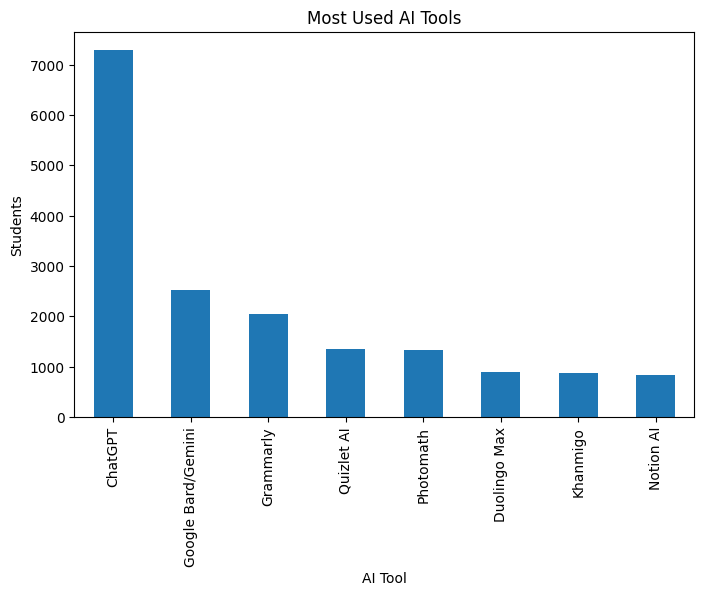

In [ ]:
plt.figure(figsize=(8,5))

df['AI_Tool_Used'].value_counts().plot(kind='bar')

plt.title("Most Used AI Tools")
plt.xlabel("AI Tool")
plt.ylabel("Students")
plt.show()

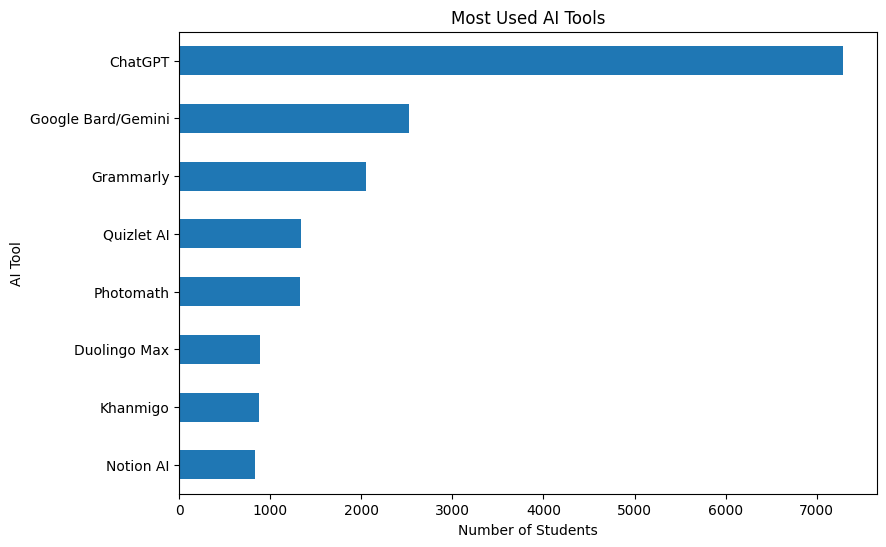

In [ ]:
plt.figure(figsize=(9,6))

df['AI_Tool_Used'].value_counts().sort_values().plot(kind='barh')

plt.title("Most Used AI Tools")
plt.xlabel("Number of Students")
plt.ylabel("AI Tool")
plt.show()

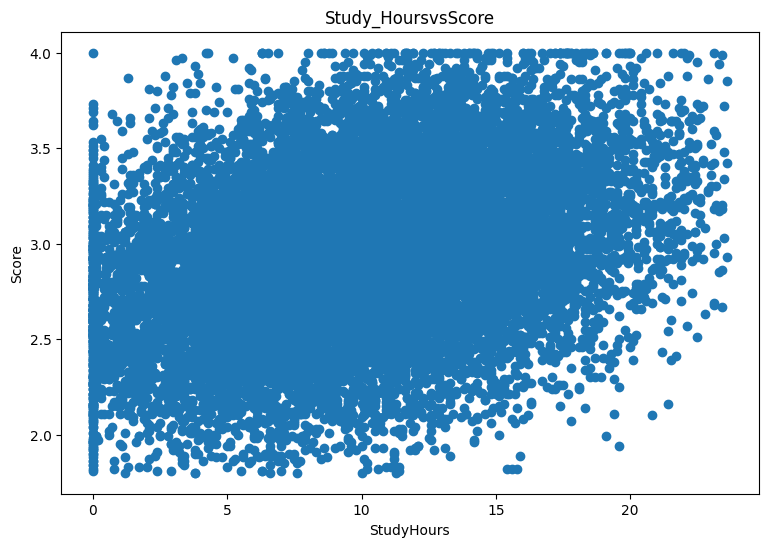

In [ ]:
plt.figure(figsize=(9,6))

plt.scatter(df['Hours_Studying_Per_Week'], df['GPA'])

plt.title("Study_HoursvsScore")
plt.xlabel("StudyHours")
plt.ylabel("Score")
plt.show()

9. Draw Insights

In [ ]:
#ChatGPT is the most frequently used AI tool.
#Students using AI spend a moderate number of hours each week with AI tools.
#GPA varies slightly across different AI tools.
#Most students use laptops for AI-based learning.
#AI is mainly used for homework and exam preparation.
#Helpfulness scores are generally high, indicating positive student perception.
#Most students spend very little or nothing on AI subscriptions.

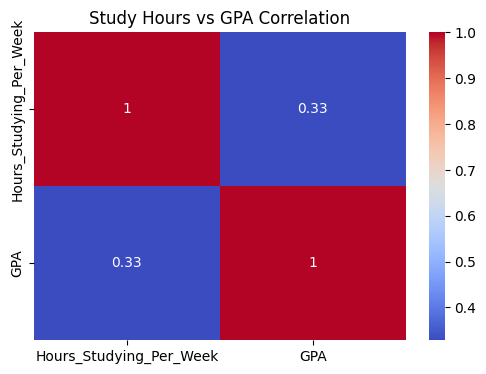

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['Hours_Studying_Per_Week', 'GPA']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Study Hours vs GPA Correlation")
plt.show()

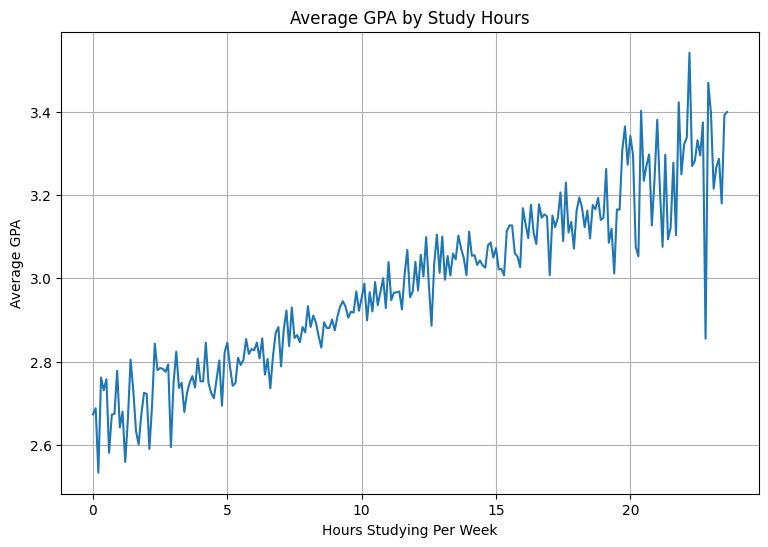

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_grouped = df.groupby('Hours_Studying_Per_Week')['GPA'].mean()

plt.figure(figsize=(9,6))
plt.plot(df_grouped.index, df_grouped.values)

plt.title("Average GPA by Study Hours")
plt.xlabel("Hours Studying Per Week")
plt.ylabel("Average GPA")
plt.grid(True)

plt.show()

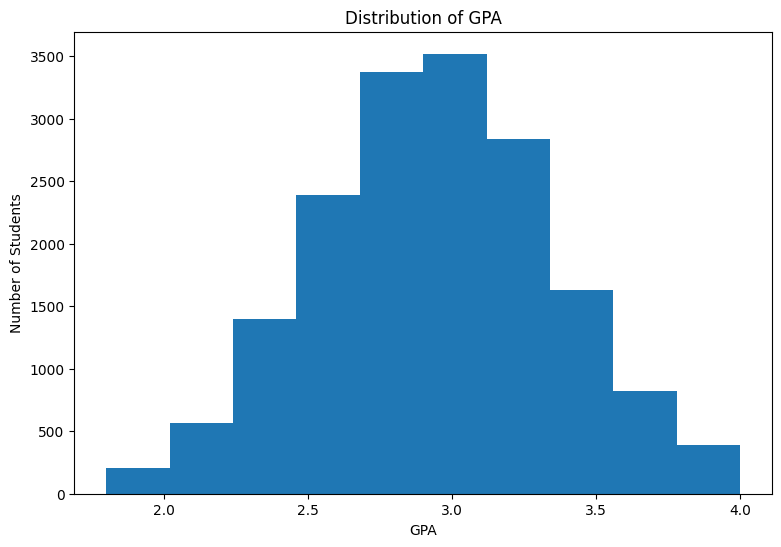

In [ ]:
plt.figure(figsize=(9,6))

plt.hist(df['GPA'], bins=10)

plt.title("Distribution of GPA")
plt.xlabel("GPA")
plt.ylabel("Number of Students")
plt.show()